In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast 
from ast import literal_eval
import os
from pathlib import Path
from pandas import json_normalize
import re
from collections import defaultdict

In [2]:
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.max_rows', None)  

In [3]:
#Se leeran todos los csv y se guardaran en diccionarios para acceder a ellos
carpeta = Path(r"C:\Users\sayur\OneDrive\Documentos\DataSets\eldenring2")
dataframes = {}
for archivo in carpeta.glob('*.csv'):
    nombre_tabla = archivo.stem  
    dataframes[nombre_tabla] = pd.read_csv(archivo,dtype=str, low_memory=False, na_filter=True)

In [4]:
#Normalizar datos del dataframe

def expand_dict_columns(df):
    """
    Expande las columnas que contienen diccionarios en nuevas columnas.
    """
    for col in df.columns:
        # Verifica si la columna contiene strings que son diccionarios
        if df[col].apply(lambda x: isinstance(x, str) and x.startswith('{') and x.endswith('}')).any():
            try:
                # Convierte el string a diccionario
                dicts = df[col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})
                # Normaliza los diccionarios y renombra columnas
                expanded = pd.json_normalize(dicts).add_prefix(f"{col}_")
                # Elimina la columna original y une las nuevas
                df = df.drop(col, axis=1).join(expanded)
            except (ValueError, SyntaxError):
                print(f"⚠️ Columna '{col}' no pudo ser normalizada (no es un diccionario válido).")
    return df
    
    dataframes[nombre_tabla] = expand_dict_columns(df)  # Normaliza aquí

# Verificar tablas normalizadas
print("Tablas cargadas:", list(dataframes.keys()))

Tablas cargadas: ['ammos', 'armors', 'ashes', 'bosses', 'classes', 'creatures', 'incantations', 'items', 'locations', 'npcs', 'shields', 'sorceries', 'spirits', 'talismans', 'weapons', 'weapons_upgrades']


In [5]:
#Convierte a numeros los valores correspondientes
def convert_to_numeric(df):
    # Identificar columnas que parecen numéricas (incluyendo las que están como strings)
    for col in df.columns:
        # Intenta convertir a numérico
        converted = pd.to_numeric(df[col], errors='coerce')
        # Si al menos el 80% de los valores se convirtieron (para no forzar columnas no numéricas)
        if not converted.isna().all():  # Si hay algún valor numérico
            df[col] = converted
    return df

# Aplicar a todas las tablas en tu diccionario
for nombre, df in dataframes.items():
    dataframes[nombre] = convert_to_numeric(df.copy())  # Usar copy() para evitar SettingWithCopyWarning

In [6]:
#Se eliminaran columnas que no se ocuparan
columnas_a_eliminar = ['image', 'description', 'id']  # Columnas redundantes
for nombre_tabla, df in dataframes.items():  
  dataframes[nombre_tabla] = df.drop(columns=columnas_a_eliminar, errors='ignore')

<Axes: title={'center': 'Armas por categoría'}, xlabel='category'>

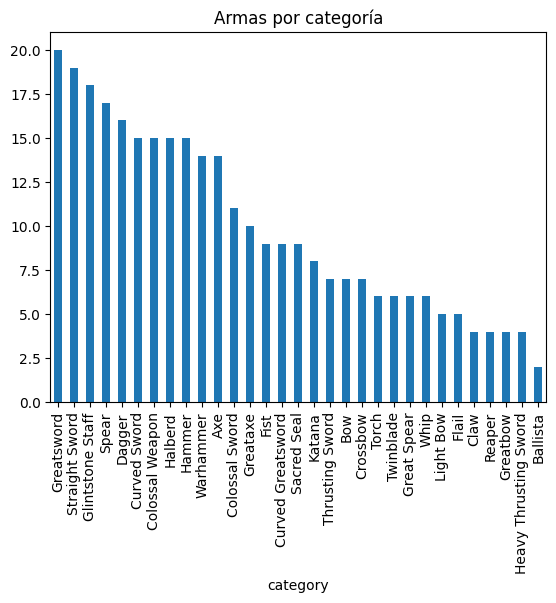

In [7]:
#Distribución de armas por categoría
df_weapons=dataframes['weapons']
df_weapons['category'].value_counts().plot(kind='bar', title='Armas por categoría')

In [8]:
df_bosses=dataframes['bosses']
df_bosses.head(3)

,name,region,location,drops,healthPoints
0,Abductor Virgins,Mount Gelmir,Volcano Manor,"['10.000 Runes', ""Inquisitor's Girandole""]",NaN
1,"Alecto, Black Knife Ringleader",Liurnia of the Lakes,"Ringleader's Evergoal, Liurnia of the Lakes","['8.000 Runes', 'Black Knife Tiche']",NaN
2,Alecto Black Knife Ringleader,Liurnia of the Lakes,Limgrave,"['80.000 Runes', 'Other Drops']",NaN


In [9]:
df_weapons.head(2)

,name,attack,defence,scalesWith,requiredAttributes,category,weight
0,Hand Axe,"[{'name': 'Phy', 'amount': 113}, {'name': 'Mag', 'amount': 0}, {'name': 'Fire', 'amount': 0}, {'name': 'Ligt', 'amount': 0}, {'name': 'Holy', 'amount': 0}, {'name': 'Crit', 'amount': 100}]","[{'name': 'Phy', 'amount': 42}, {'name': 'Mag', 'amount': 28}, {'name': 'Fire', 'amount': 28}, {'name': 'Ligt', 'amount': 28}, {'name': 'Holy', 'amount': 28}, {'name': 'Boost', 'amount': 28}]","[{'name': 'Str', 'scaling': 'D'}, {'name': 'Dex', 'scaling': 'D'}]","[{'name': 'Str', 'amount': 9}, {'name': 'Dex', 'amount': 8}]",Axe,3.5
1,Jawbone Axe,"[{'name': 'Phy', 'amount': 124}, {'name': 'Mag', 'amount': 0}, {'name': 'Fire', 'amount': 0}, {'name': 'Ligt', 'amount': 0}, {'name': 'Holy', 'amount': 0}, {'name': 'Crit', 'amount': 100}]","[{'name': 'Phy', 'amount': 49}, {'name': 'Mag', 'amount': 33}, {'name': 'Fire', 'amount': 33}, {'name': 'Ligt', 'amount': 33}, {'name': 'Holy', 'amount': 33}, {'name': 'Boost', 'amount': 36}]","[{'name': 'Str', 'scaling': 'D'}, {'name': 'Dex', 'scaling': 'E'}]","[{'name': 'Str', 'amount': 14}, {'name': 'Dex', 'amount': 8}]",Axe,5.5


In [10]:
#Se normalizaran los diccionarios que quedan

def expand_list_of_dicts(df, column_name):
    """
    Expande una columna con listas de diccionarios en múltiples columnas.
    """
    try:
        # Convertir strings a listas de diccionarios
        data = df[column_name].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
    except (ValueError, SyntaxError):
        print(f"⚠️ Error al procesar {column_name}. Verifica el formato.")
        return df
    
    # Recolectar todos los posibles 'name' en los diccionarios
    all_names = set()
    for item in data.explode():
        if isinstance(item, dict):
            all_names.add(item.get('name'))
    
    # Crear nuevas columnas
    new_columns = defaultdict(list)
    for items in data:
        if not isinstance(items, list):
            items = []
        # Inicializar valores para todos los nombres
        temp = {name: None for name in all_names}
        for item in items:
            if isinstance(item, dict):
                name = item.get('name')
                if 'amount' in item:
                    temp[name] = item.get('amount')
                elif 'scaling' in item:
                    temp[name] = item.get('scaling')
        for name in all_names:
            new_columns[f"{column_name}_{name}"].append(temp[name])
    
    # Añadir nuevas columnas al DataFrame
    for name in all_names:
        df[f"{column_name}_{name}"] = new_columns[f"{column_name}_{name}"]
    
    return df

def normalize_all_dataframes(dataframes_dict):
    """
    Normaliza todas las columnas relevantes en cada DataFrame del diccionario.
    """
    for table_name, df in dataframes_dict.items():
        #print(f"🔍 Procesando tabla: {table_name}")
        # Columnas a evaluar (ej: attack, defence, scalesWith, etc.)
        columns_to_check = df.columns
        for col in columns_to_check:
            # Verificar si la columna contiene listas de diccionarios
            sample_value = df[col].dropna().iloc[0] if not df[col].dropna().empty else ""
            if isinstance(sample_value, str) and sample_value.startswith('[') and sample_value.endswith(']'):
                try:
                    sample_eval = ast.literal_eval(sample_value)
                    if isinstance(sample_eval, list) and len(sample_eval) > 0 and isinstance(sample_eval[0], dict):
                        #print(f"   ➡️ Normalizando columna: {col}")
                        df = expand_list_of_dicts(df, col)
                except (ValueError, SyntaxError):
                    continue
        dataframes_dict[table_name] = df
    return dataframes_dict

# Aplicar a todas las tablas en 'dataframes'
dataframes = normalize_all_dataframes(dataframes)

# Verificar resultados
for name, df in dataframes.items():
    #print(f"\n📊 Tabla: {name}")
    #print("Columnas:", df.columns.tolist())
    print("Hecho")

Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho
Hecho


In [11]:
#Se ajustan las columnas con valores numericos
for df in dataframes.values():
    for col in df.columns:
        if 'amount' in col:
            df[col] = pd.to_numeric(df[col], errors='ignore')

In [12]:
df_weapons.head(1)

,name,attack,defence,scalesWith,requiredAttributes,category,weight,attack_Ligt,attack_Sorc,attack_Sor,...,requiredAttributes_,requiredAttributes_INT,requiredAttributes_Str,requiredAttributes_DEX,requiredAttributes_Fai,requiredAttributes_Int,requiredAttributes_Arc,requiredAttributes_Dex,requiredAttributes_STR,requiredAttributes_-
0,Hand Axe,"[{'name': 'Phy', 'amount': 113}, {'name': 'Mag', 'amount': 0}, {'name': 'Fire', 'amount': 0}, {'name': 'Ligt', 'amount': 0}, {'name': 'Holy', 'amount': 0}, {'name': 'Crit', 'amount': 100}]","[{'name': 'Phy', 'amount': 42}, {'name': 'Mag', 'amount': 28}, {'name': 'Fire', 'amount': 28}, {'name': 'Ligt', 'amount': 28}, {'name': 'Holy', 'amount': 28}, {'name': 'Boost', 'amount': 28}]","[{'name': 'Str', 'scaling': 'D'}, {'name': 'Dex', 'scaling': 'D'}]","[{'name': 'Str', 'amount': 9}, {'name': 'Dex', 'amount': 8}]",Axe,3.5,0.0,NaN,NaN,...,NaN,NaN,9.0,NaN,NaN,NaN,NaN,8.0,NaN,NaN


In [14]:
# Buscar bosses en Leyndell 
bosses_leyndell = dataframes['bosses'][
    dataframes['bosses']['location'].str.contains(r'\bLeyndell\b', case=False, na=False)
]

In [15]:
bosses_leyndell

,name,region,location,drops,healthPoints
12,Bell Bearing Hunter,Dragonbarrow,"Warmaster's Shack, Northern Stormhill, Church of Vows, East Liurnia, Hermit Merchant's Shack, Leyndell Royal Captial, Dragonbarrow, North Caelid","['2700 Runes', ""Bone Peddler's Bell Bearing""]",NaN
37,"Esgar, Priest Of Blood",Altus Plateau,"Leyndell, Royal Capital","['30000 Runes', ""Lord of Blood's Exultation""]",NaN
51,"Godfrey, First Elden Lord (hoarah Loux)",Altus Plateau,"Leyndell, Capital of Ash","['300,000 Runes', 'Remembrance of Hoarah Loux']",NaN
52,"Godfrey, First Elden Lord (golden Shade)",Altus Plateau,"Leyndell, Royal Capital","['80,000 Runes', 'Talisman Pouch']",NaN
61,"Hoarah Loux, Warrior",Altus Plateau,"Leyndell, Ashen Capital.","['300000 Runes', 'Remembrance of Hoarah Loux']",NaN
97,"Sir Gideon Ofnir, The All-knowing",Altus Plateau,"Leyndell, Capital of Ash","['180,000 Runes', 'All-Knowing Helm', 'All-Knowing Armor', 'All-Knowing Gauntlets', 'All-Knowing Greaves', 'Scepter of the All-Knowing']",NaN


<Axes: title={'center': 'Bosses por region'}, xlabel='region'>

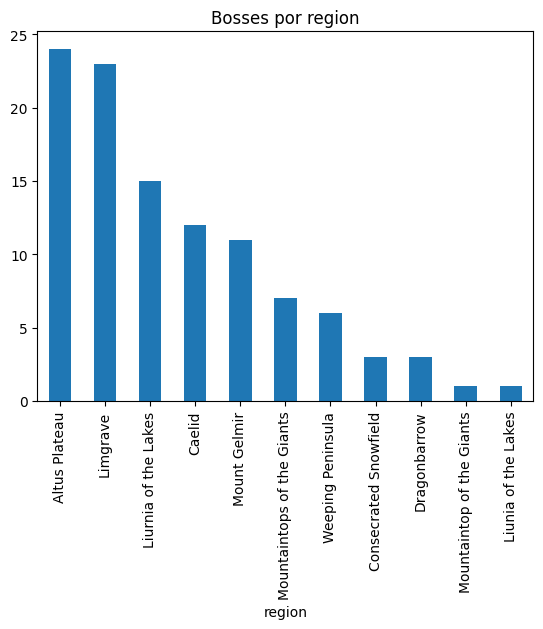

In [16]:
#Distribución de bosses por region
df_bosses['region'].value_counts().plot(kind='bar', title='Bosses por region')

In [30]:
# Creaturas por ubicacion
df_creatures=dataframes['creatures']
creatures_leyndell = dataframes['creatures'][
    dataframes['creatures']['location'].str.contains(r'\bLeyndell\b', case=False, na=False)
]
creatures_leyndell.head(5)

,name,location,drops
57,Perfumer,Leyndell Royal Capital,['563 Runes']
71,Golem,"West ruins of Stormhill., Castle Morne Entrance, Ainsel River Well, Leyndell, Royal Capital","['3x Smithing Stone Shard', '844~1039 Runes']"
98,Perfumer,Leyndell Royal Capital,['563 Runes']


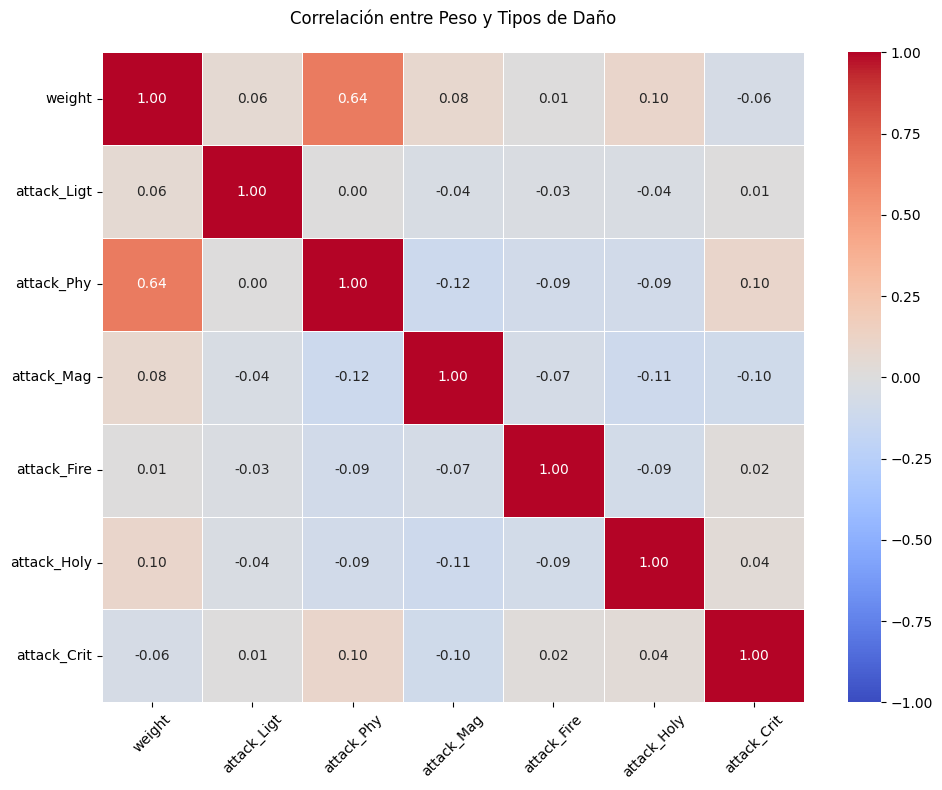

In [18]:
#Relacion de peso y dmg

# 1. Selección y limpieza de columnas numéricas
damage_cols = ['weight', 'attack_Ligt', 'attack_Phy', 'attack_Mag', 'attack_Fire', 'attack_Holy', 'attack_Crit']
df_numeric = df_weapons[damage_cols].apply(pd.to_numeric, errors='coerce').dropna()

# 2. Matriz de correlación
corr_matrix = df_numeric.corr()

# 3. Heatmap mejorado
plt.figure(figsize=(10, 8))
sns.heatmap(
    data=corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,  # Rango fijo para mejor interpretación
    vmax=1,
    linewidths=0.5,
)
plt.title("Correlación entre Peso y Tipos de Daño", pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
#10 Armas mas livianas

df_weapons.nsmallest(10, 'weight')[['name', 'weight', 'category']]

,name,weight,category
106,Cipher Pata,0.0,Fist
140,Gargoyle's Great Axe,0.0,Greataxe
227,Golden Order Seal,0.0,Sacred Seal
228,Erdtree Seal,0.0,Sacred Seal
229,Erdtree Seal,0.0,Sacred Seal
230,Dragon Communion Seal,0.0,Sacred Seal
231,Frenzied Flame Seal,0.0,Sacred Seal
26,Raptor Talons,1.5,Claw
82,Dagger,1.5,Dagger
85,Parrying Dagger,1.5,Dagger


In [31]:
#10 Armas mas pesadas
df_weapons.nlargest(10, 'weight')[['name', 'weight', 'category']]

,name,weight,category
48,Giant-crusher,26.5,Colossal Weapon
41,Prelate's Inferno Crozier,23.5,Colossal Weapon
28,Greatsword,23.0,Colossal Sword
35,Ruins Greatsword,23.0,Colossal Sword
27,Watchdog's Greatsword,22.0,Colossal Sword
30,Maliketh's Black Blade,22.0,Colossal Sword
45,Fallingstar Beast Jaw,21.5,Colossal Weapon
49,Golem's Halberd,21.5,Colossal Weapon
34,Grafted Blade Greatsword,21.0,Colossal Sword
32,Royal Greatsword,20.0,Colossal Sword
